In [114]:
import scanpy as sc
import anndata as ad
import scipy.io
import pandas as pd
import gzip

# 데이터 불러오는 함수
def load_adata(matrix_file, features_file, barcodes_file, sample_name):
    with gzip.open(matrix_file, "rb") as f:
        X = scipy.io.mmread(f).tocsr().T  # 🔹 행렬 전치 (유전자가 열이 되도록)
    
    with gzip.open(features_file, "rt") as f:
        genes = pd.read_csv(f, sep="\t", header=None, names=["gene_id", "gene_name", "feature_type"])
    
    with gzip.open(barcodes_file, "rt") as f:
        barcodes = pd.read_csv(f, sep="\t", header=None, names=["barcode"])
    
    # AnnData 객체 생성
    adata = ad.AnnData(X)
    
    # 🔹 유전자 이름이 중복될 경우 수정
    adata.var = genes[["gene_name"]]
    adata.var_names = genes["gene_name"]
    adata.var_names_make_unique()  # 🔹 중복된 유전자 이름 해결

    # 🔹 세포 바코드 중복 방지
    adata.obs_names = barcodes["barcode"]
    adata.obs_names_make_unique()  # 🔹 중복된 세포 바코드 해결
    adata.obs["sample"] = sample_name  # 샘플 정보 추가
    
    return adata

# 샘플 정보 및 파일 경로 설정
base_path = "/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Colorectal/"
samples = [
    "GSM8560288_Mono_CAF_alone",
    "GSM8560289_Mono_CAF_24h",
    "GSM8560290_Macro_CAF_alone",
    "GSM8560291_Macro_CAF_24h",
    "GSM8560294_Triple_culture_O-IAV",
    "GSM8560293_Triple_culture_oxali_5FU",
    "GSM8560292_Triple_culture_mock"
]

# AnnData 객체 생성 및 리스트에 저장
adata_list = []
for sample in samples:
    matrix_file = f"{base_path}{sample}_matrix.mtx.gz"
    features_file = f"{base_path}{sample}_features.tsv.gz"
    barcodes_file = f"{base_path}{sample}_barcodes.tsv.gz"
    adata_list.append(load_adata(matrix_file, features_file, barcodes_file, sample.split("_", 1)[1]))

# 🔹 AnnData 객체 병합
adata = ad.concat(adata_list, axis=0, join="outer", label="sample", keys=[s.split("_", 1)[1] for s in samples])
print(adata.X.shape)

(46016, 36601)


In [160]:
import scanpy as sc
import anndata as ad
import os

# 데이터가 저장된 디렉토리
data_dir = "/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Colorectal/"

# 샘플 이름 리스트 (prefix 기준)
sample_prefixes = [
    "GSM8545950_P17-T1",
    "GSM8545951_P17-T3",
    "GSM8545952_P18-T1",
    "GSM8545953_P18-T3",
    "GSM8545954_P19-T1",
    "GSM8545955_P19-T3"
]

# adata 저장 리스트
adatas = []

# 각 샘플별로 읽어서 sample 정보 붙이고 리스트에 추가
for prefix in sample_prefixes:
    adata = sc.read_10x_mtx(
        path=data_dir,
        var_names="gene_symbols",
        make_unique=True,
        prefix=prefix + "-"
    )
    adata.obs["sample"] = prefix
    adatas.append(adata)

# 모든 샘플을 하나의 AnnData로 병합
adata= ad.concat(adatas, join="outer", label="sample_id", keys=sample_prefixes)

# 저장 (선택)
# adata_merged.write_h5ad(os.path.join(data_dir, "GSE278406_merged.h5ad"))


In [200]:
import scanpy as sc

# 파일 경로 지정
file_path = "/home/Data_Drive_8TB/kykim/temp_rds/total_CRC_final_counts_active.h5ad"

# h5ad 파일을 AnnData 객체로 로드
adata = sc.read_h5ad(file_path)

In [210]:
adata.obs['sample'] = 'SNU_' + adata.obs['patients'].astype(str)
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,patients,MSS,KRAS,KRAS.mutation,Location,Stage,snv_sum,...,Annotation_total_Trough,annotation_tmp,Celltype_Fig1,Annotation_Fig1,Annotation_Fig1A,Annotation_tmp_fr,Annotation_cell2loc_onlyEpiT,Annotation_cell2loc,Annotation_cell2loc_onlyEpicebpbhl_T,sample
AAACCTGAGGTGTGGT-1,SeuratProject,2792.0,1097,H1,MSS,KRAS mutation,KRAS G12V,D-colon,T3cN0,340,...,CD19B,CD19B,B,CD19B,B,CD19B,Others,B,Others,SNU_H1
AAACCTGCACGAAGCA-1,SeuratProject,37388.0,2465,H1,MSS,KRAS mutation,KRAS G12V,D-colon,T3cN0,790,...,plasmaB,plasmaB,Plasma,plasmaB,Plasma,plasmaB,Others,Plasma,Others,SNU_H1
AAACCTGCAGATGGGT-1,SeuratProject,1228.0,601,H1,MSS,KRAS mutation,KRAS G12V,D-colon,T3cN0,198,...,Myeloid,Myeloid,Myeloid,Myeloid,Myeloid,Myeloid,Others,Myeloid,Others,SNU_H1
AAACCTGCAGCTGCTG-1,SeuratProject,1371.0,633,H1,MSS,KRAS mutation,KRAS G12V,D-colon,T3cN0,148,...,Unknown,T/NK,CD4T,Unknown,T/NK,Unknown,Others,Unknown,Others,SNU_H1
AAACCTGCATCCCACT-1,SeuratProject,4797.0,1465,H1,MSS,KRAS mutation,KRAS G12V,D-colon,T3cN0,386,...,Epithelial,Epithelial,Epithelial,Epithelial,Epithelial,Epithelial,Epithelial,Epithelial,Epithelial,SNU_H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAAGATGGGTC-31,SeuratProject,718.0,383,H31,MSS,KRAS WT,unknown,S-colon,T2N0,Unknown,...,Myeloid,Myeloid,Myeloid,Myeloid,Myeloid,Myeloid,Others,Myeloid,Others,SNU_H31
TTTGTCAAGGCATGTG-31,SeuratProject,13298.0,3700,H31,MSS,KRAS WT,unknown,S-colon,T2N0,Unknown,...,Cycling cells,Cycling cells,Epithelial,Epithelial,Epithelial,Cycling cells,Others,Epithelial,Others,SNU_H31
TTTGTCAAGTCGCCGT-31,SeuratProject,5686.0,2325,H31,MSS,KRAS WT,unknown,S-colon,T2N0,Unknown,...,CD4_T,T/NK,CD4T,CD4T,T/NK,CD4 Th17,CD4T,CD4T,CD4T,SNU_H31
TTTGTCAAGTCTCGGC-31,SeuratProject,12223.0,3204,H31,MSS,KRAS WT,unknown,S-colon,T2N0,Unknown,...,Myeloid,Myeloid,Myeloid,Myeloid,Myeloid,Myeloid,Others,Myeloid,Others,SNU_H31


In [41]:
import scanpy as sc

# 10x Genomics 형식의 h5 파일 경로
input_path = "/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Colorectal/GSM8657093_141T_filtered_feature_bc_matrix.h5"

# 읽기 (10x 형식 자동 인식)
adata = sc.read_10x_h5(input_path)

# 세포와 유전자 이름 중복 방지 (옵션)
adata.var_names_make_unique()
# 샘플 이름
sample_id = "GSM8657093_141T"

# 기존 index 확인
print("Before:", adata.obs_names[:5])

# prefix 붙이기 (예: GSM8657093_141T_AAACCCAAGTTCAGGA-1)
adata.obs_names = [f"{sample_id}_{bc}" for bc in adata.obs_names]

print("After:", adata.obs_names[:5])



Before: Index(['AAACCCACAACCTATG-1', 'AAACCCAGTATCACGT-1', 'AAACCCAGTCACGTGC-1',
       'AAACCCAGTGACTGAG-1', 'AAACCCAGTGGATTTC-1'],
      dtype='object')
After: Index(['GSM8657093_141T_AAACCCACAACCTATG-1',
       'GSM8657093_141T_AAACCCAGTATCACGT-1',
       'GSM8657093_141T_AAACCCAGTCACGTGC-1',
       'GSM8657093_141T_AAACCCAGTGACTGAG-1',
       'GSM8657093_141T_AAACCCAGTGGATTTC-1'],
      dtype='object')


In [62]:
import pandas as pd
import scipy.io
import scipy.sparse
from anndata import AnnData

# 경로 지정
data_path = "/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Colorectal/"

# 각 파일 경로
matrix_file = data_path + "GSM8527251_M1001-matrix.mtx.gz"
features_file = data_path + "GSM8527251_M1001-features.tsv.gz"
barcodes_file = data_path + "GSM8527251_M1001-barcodes.tsv.gz"

# 1. matrix 파일 읽기 (희소 행렬)
matrix = scipy.io.mmread(matrix_file).tocsc()

# 2. features 파일 읽기 (gene 정보)
features = pd.read_csv(features_file, header=None, sep='\t')
features.columns = ['gene_id', 'gene_symbol', 'feature_type']

# 3. barcodes 파일 읽기 (세포 barcode 정보)
barcodes = pd.read_csv(barcodes_file, header=None)[0].tolist()

# 4. AnnData 객체 생성
adata = AnnData(
    X=matrix.transpose(),  # cells x genes 구조로 transpose
)

# 5. 변수(var, gene) 및 관측(obs, cell) 정보 추가
adata.var_names = features['gene_symbol'].astype(str)
adata.var['gene_ids'] = features['gene_id'].astype(str)
adata.obs_names = barcodes
adata.var_names_make_unique()
# 결과 확인
print(adata)


AnnData object with n_obs × n_vars = 3098 × 33538
    var: 'gene_ids'


In [161]:
import pandas as pd
import scanpy as sc

file_path = "/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Colorectal/GSE200997_GEO_processed_CRC_10X_raw_UMI_count_matrix.csv.gz"

# gene 이름이 첫 번째 column, cell barcodes는 column header에 있음
df = pd.read_csv(file_path, index_col=0)  # 쉼표 구분이 맞음

# 구조 확인
print("Shape:", df.shape)
print("Gene names (index):", df.index[:5].tolist())
print("Cell barcodes (columns):", df.columns[:5].tolist())

# AnnData로 변환
adata = sc.AnnData(df.T)  # Transpose: cell x gene
adata.var_names_make_unique()

# 결과 확인
print(adata)


KeyboardInterrupt: 

In [207]:
import scanpy as sc
import pandas as pd

# 파일 경로 지정
file_path = "/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Colorectal/GSE132465_GEO_processed_CRC_10X_raw_UMI_count_matrix.txt.gz"

# 텍스트 파일을 pandas로 불러오기 (index가 gene명일 경우)
df = pd.read_csv(file_path, sep="\t", index_col=0)

# AnnData 객체로 변환
adata = sc.AnnData(df.T)  # transpose: cells x genes 구조로 맞춤


In [208]:
adata.obs['sample'] = ['GSE132465_' + idx.split('_')[0] for idx in adata.obs.index]

In [209]:
adata = adata[adata.obs['sample'].str.endswith('T'), :].copy()

In [210]:
adata.obs

,sample
SMC01-T_AAACCTGCATACGCCG,GSE132465_SMC01-T
SMC01-T_AAACCTGGTCGCATAT,GSE132465_SMC01-T
SMC01-T_AAACCTGTCCCTTGCA,GSE132465_SMC01-T
SMC01-T_AAACGGGAGGGAAACA,GSE132465_SMC01-T
SMC01-T_AAACGGGGTATAGGTA,GSE132465_SMC01-T
...,...
SMC25-T_TTTGGTTCAACGCACC,GSE132465_SMC25-T
SMC25-T_TTTGTCAAGCGCTCCA,GSE132465_SMC25-T
SMC06-T_TCTTCGGCAAACAACA,GSE132465_SMC06-T
SMC07-T_TGAGAGGGTTTAGGAA,GSE132465_SMC07-T


In [239]:
import scanpy as sc
import os

# 데이터 경로
base_dir = "/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Colorectal/"

# 명시적으로 사용할 샘플 리스트 (파일명 접두어)
sample_ids = [
    "GSM4904234_Patient0_carcinoma",
    "GSM4904235_Patient1_adenoma",
    "GSM4904236_Patient1_carcinoma",
    "GSM4904238_Patient2_adenoma",
    "GSM4904239_Patient2_carcinoma",
    "GSM4904241_Patient2_para-cancer",
    "GSM4904242_Patient3_adenoma_1",
    "GSM4904243_Patient3_adenoma_2",
    "GSM4904244_Patient3_blood",
    "GSM4904245_Patient3_carcinoma",
]

# 샘플별로 AnnData 객체 불러오고 sample 정보 추가
adatas = []
for sid in sample_ids:
    matrix_path = os.path.join(base_dir, f"{sid}_matrix.mtx.gz")
    barcodes_path = os.path.join(base_dir, f"{sid}_barcodes.tsv.gz")
    features_path = os.path.join(base_dir, f"{sid}_features.tsv.gz")

    adata = sc.read_10x_mtx(
        path=base_dir,
        var_names='gene_symbols',
        make_unique=True,
        prefix=sid + '_'
    )
    adata.obs['sample'] = sid
    adatas.append(adata)

# 병합
adata_all = adatas[0].concatenate(adatas[1:], batch_key="batch", batch_categories=sample_ids)
adata_all.obs['sample'] = adata_all.obs['batch']

print(f"최종 merged shape: {adata_all.shape}")


최종 merged shape: (39181, 33538)


In [242]:
del adata_all.obs['batch']


In [243]:
adata_all.obs

,sample
AAACCTGAGGTGATAT-1-GSM4904234_Patient0_carcinoma,GSM4904234_Patient0_carcinoma
AAACCTGAGTACACCT-1-GSM4904234_Patient0_carcinoma,GSM4904234_Patient0_carcinoma
AAACCTGCAGCTGGCT-1-GSM4904234_Patient0_carcinoma,GSM4904234_Patient0_carcinoma
AAACCTGGTCACACGC-1-GSM4904234_Patient0_carcinoma,GSM4904234_Patient0_carcinoma
AAACCTGGTGCAACTT-1-GSM4904234_Patient0_carcinoma,GSM4904234_Patient0_carcinoma
...,...
TTTGTCAAGTGTTGAA-1-GSM4904245_Patient3_carcinoma,GSM4904245_Patient3_carcinoma
TTTGTCAAGTTAGGTA-1-GSM4904245_Patient3_carcinoma,GSM4904245_Patient3_carcinoma
TTTGTCACACACAGAG-1-GSM4904245_Patient3_carcinoma,GSM4904245_Patient3_carcinoma
TTTGTCACAGTAGAGC-1-GSM4904245_Patient3_carcinoma,GSM4904245_Patient3_carcinoma


In [244]:
adata = adata_all
adata

AnnData object with n_obs × n_vars = 39181 × 33538
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

... storing 'feature_types' as categorical


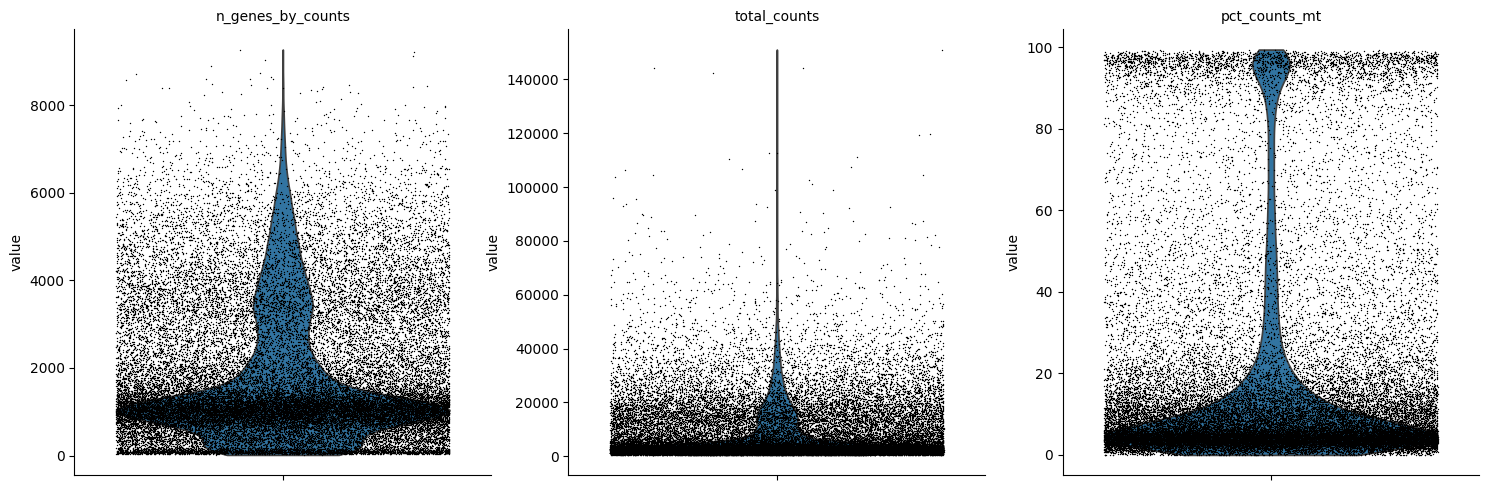

(39181, 33538)


In [246]:
import scanpy as sc
adata.layers["counts"] = adata.X.copy()
raw_var_names = adata.var_names.copy()

rawadata = adata.copy()

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


print(adata.X.shape)

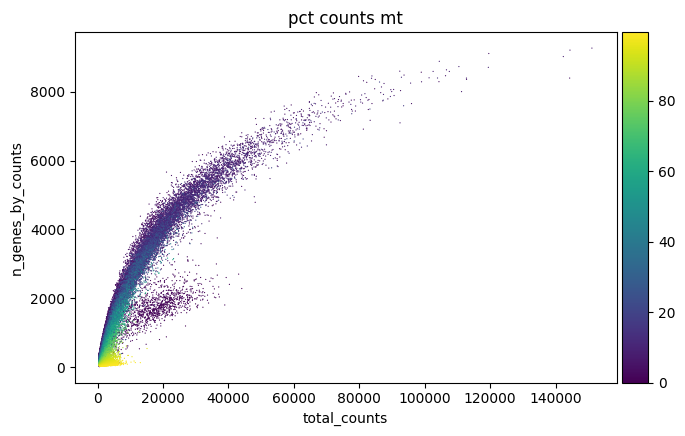

(37481, 23495)


In [247]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
print(adata.X.shape)

In [213]:
adata

AnnData object with n_obs × n_vars = 47285 × 25068
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'counts'

In [248]:
sc.pp.scrublet(adata)

In [249]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
print(adata.X.shape)

(37481, 23495)


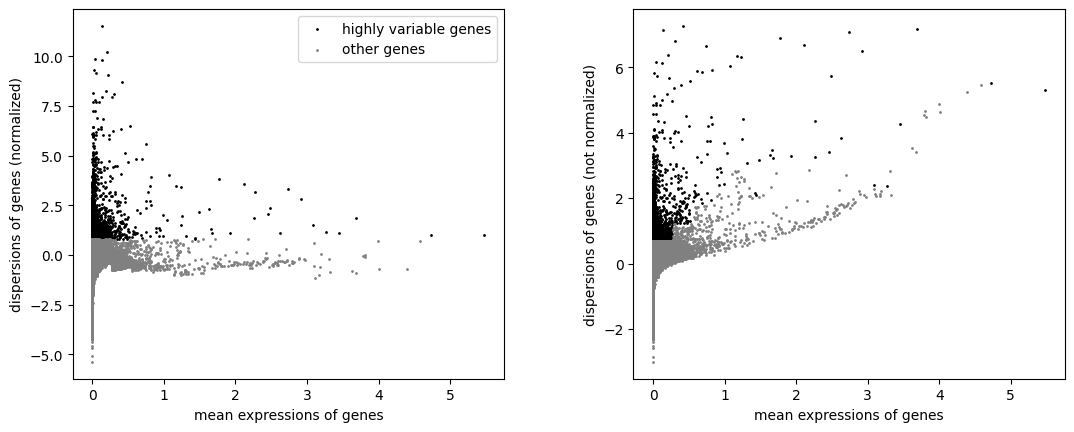

In [250]:
sc.pl.highly_variable_genes(adata)

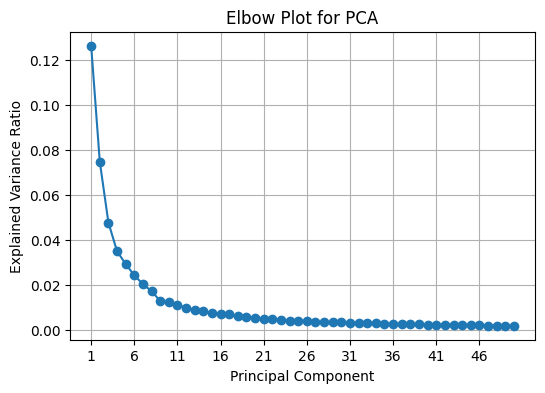

In [251]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

sc.tl.pca(adata)
explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o", linestyle="-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Elbow Plot for PCA")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, step=5))
plt.grid()
plt.show()

sc.tl.pca(adata, n_comps=26)

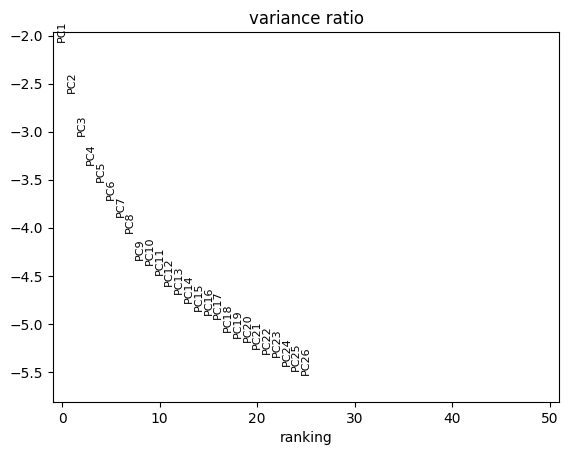

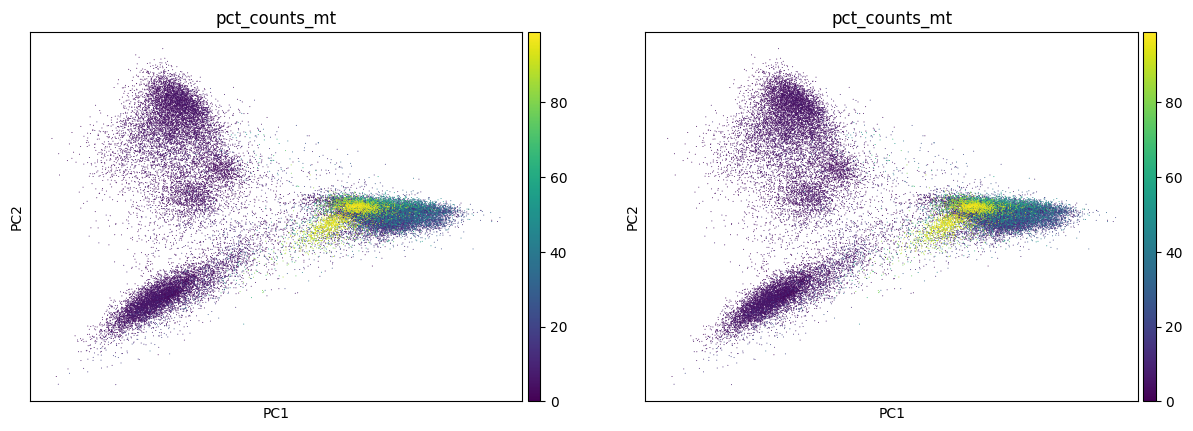

In [252]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pl.pca(
    adata,
    color=["pct_counts_mt", "pct_counts_mt"],
    ncols=2,
    size=2,
)

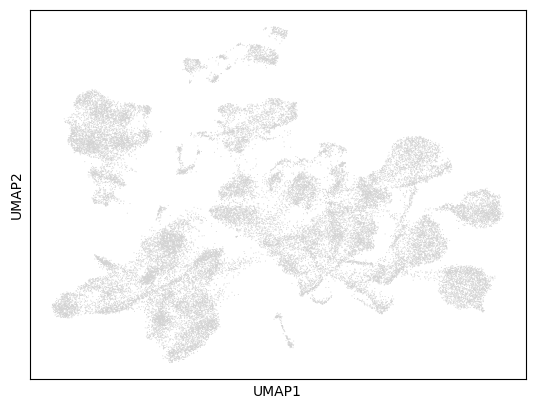

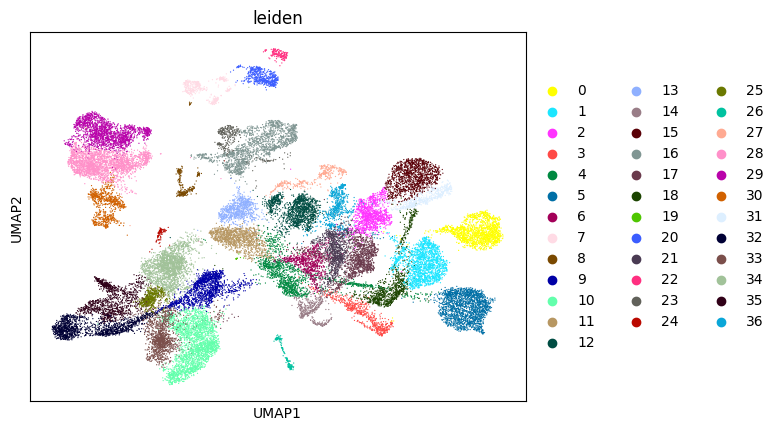

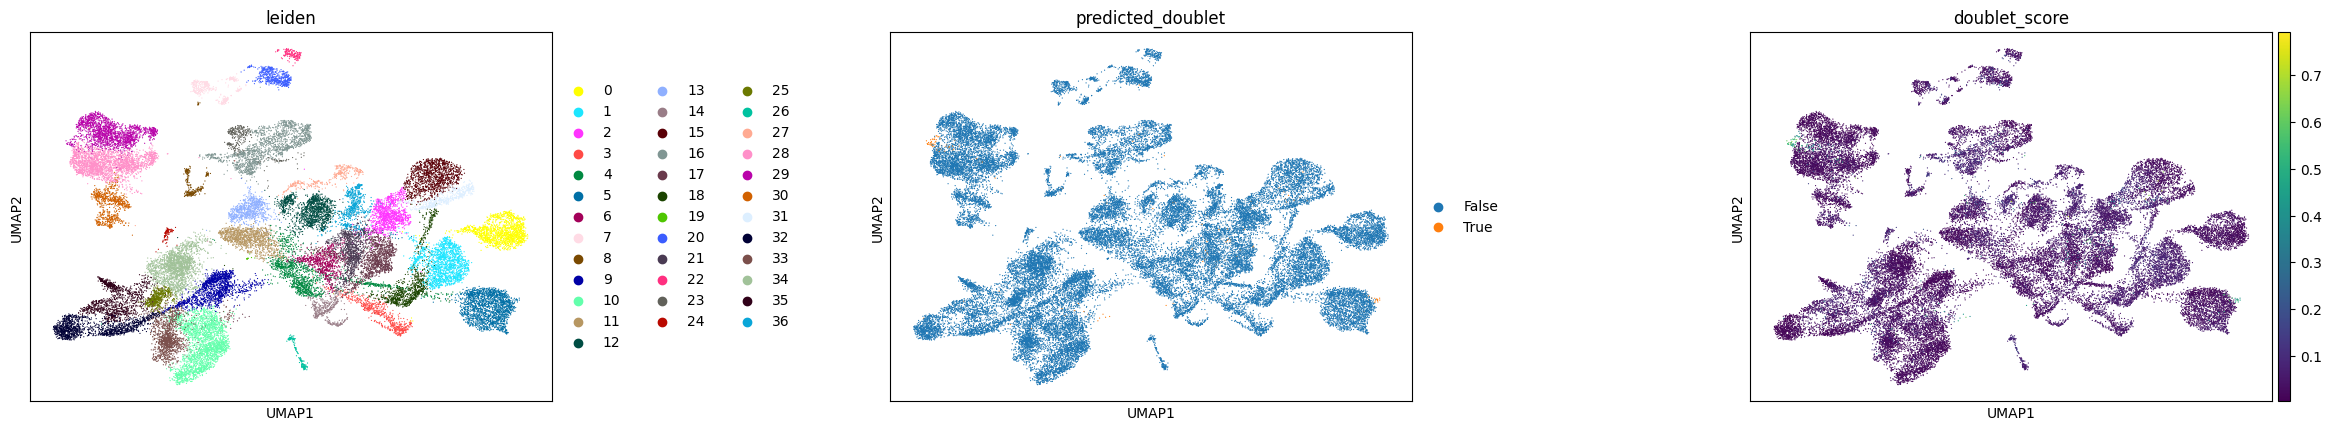

In [253]:
import bbknn 

# bbknn.bbknn(adata, batch_key='sample')
sc.pp.neighbors(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    size=2,
)
sc.pl.umap(adata, color=["leiden"])
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

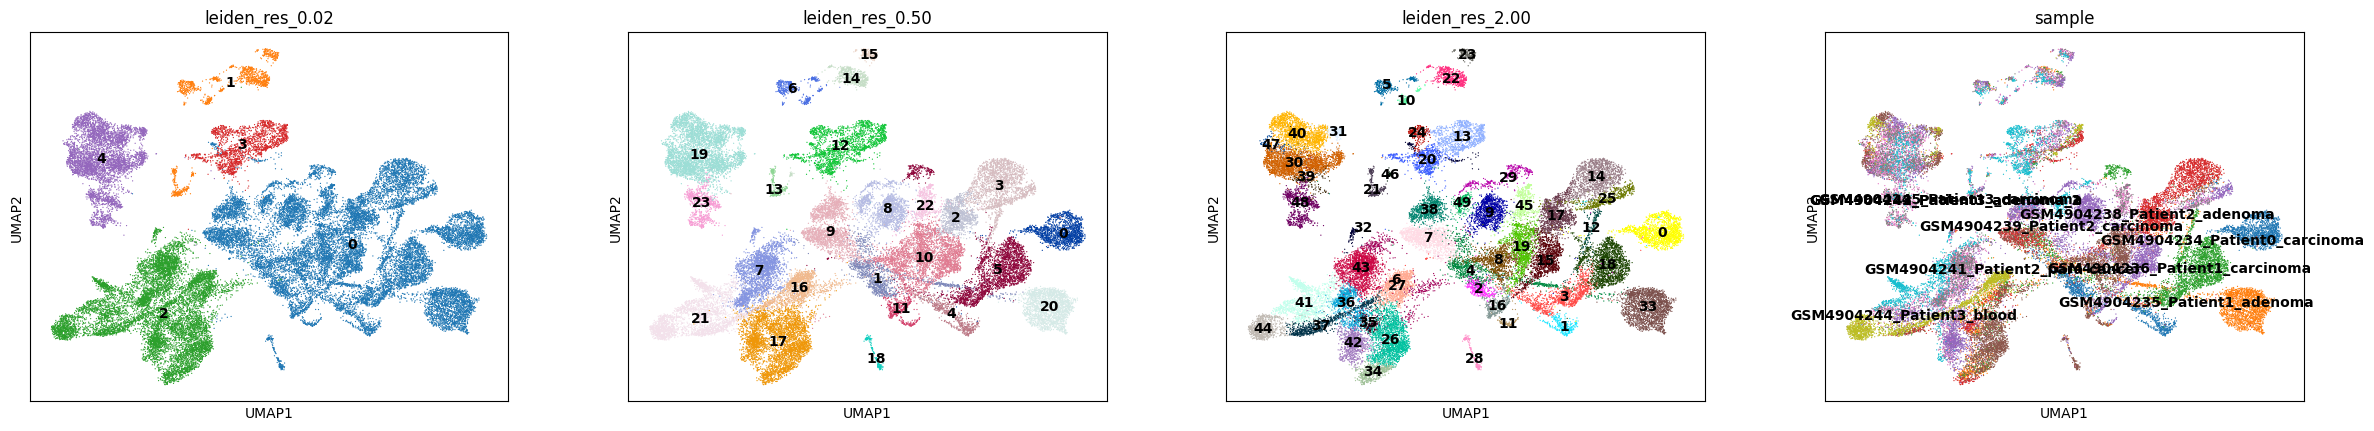

In [254]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00",'sample'],
    legend_loc="on data",
)

In [31]:
import celltypist
from celltypist import models
models.download_models(force_update = True)
models.models_description()

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 54
📂 Storing models in /home/Data_Drive_8TB/kykim/.celltypist/data/models
💾 Downloading model [1/54]: Immune_All_Low.pkl
💾 Downloading model [2/54]: Immune_All_High.pkl
💾 Downloading model [3/54]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/54]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/54]: Adult_Human_MTG.pkl
💾 Downloading model [6/54]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/54]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/54]: Adult_Human_Skin.pkl
💾 Downloading model [9/54]: Adult_Human_Vascular.pkl
💾 Downloading model [10/54]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/54]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/54]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/54]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/54]: Autopsy_COVID19_Lung.pkl
💾 Downloading model [15/54]: COVID19_HumanCh

,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
5,Adult_Human_PancreaticIslet.pkl,cell types from pancreatic islets of healthy a...
6,Adult_Human_PrefrontalCortex.pkl,cell types and subtypes from the adult human d...
7,Adult_Human_Skin.pkl,cell types from human healthy adult skin
8,Adult_Human_Vascular.pkl,vascular populations combined from multiple ad...
9,Adult_Mouse_Gut.pkl,cell types in the adult mouse gut combined fro...


In [149]:
# 'sample' 컬럼을 문자열로 변환한 후 인덱스와 결합
adata.obs.index = adata.obs['sample'].astype(str) + "_" + adata.obs.index.astype(str)


⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 37481 cells and 23495 genes
🔗 Matching reference genes in the model
🧬 5823 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


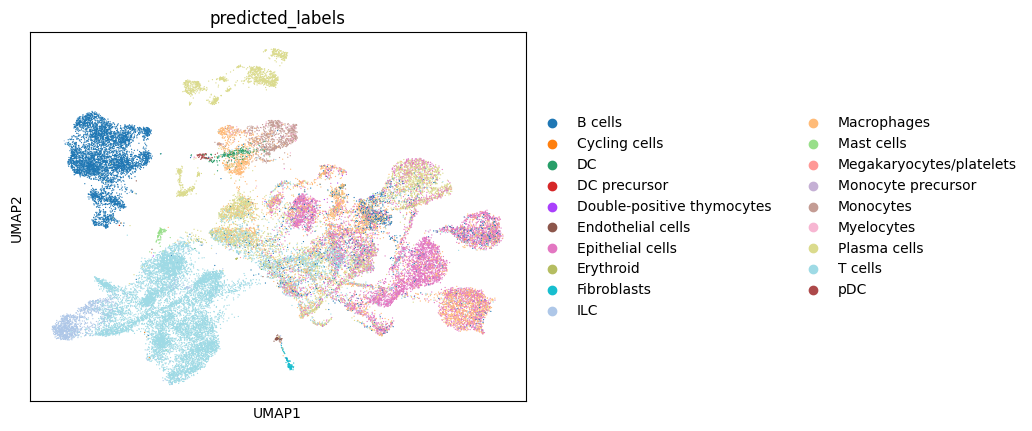

In [256]:
predictions = celltypist.annotate(adata, model = 'Immune_All_High.pkl', majority_voting = True)
adata = predictions.to_adata()
sc.pl.umap(adata, color = ['predicted_labels'])

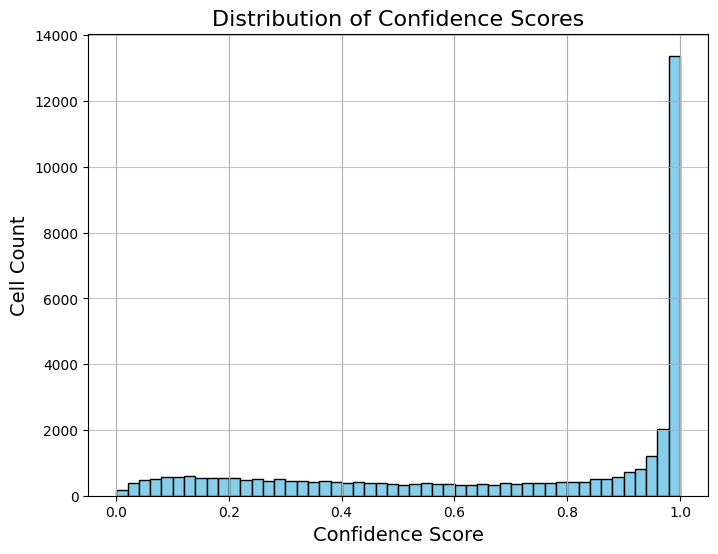

In [257]:
import matplotlib.pyplot as plt

# Check if 'conf_score' exists in Iadata.obs
if 'conf_score' in adata.obs:
    # Plot a histogram of conf_score
    plt.figure(figsize=(8, 6))
    adata.obs['conf_score'].hist(bins=50, color='skyblue', edgecolor='black')
    plt.title('Distribution of Confidence Scores', fontsize=16)
    plt.xlabel('Confidence Score', fontsize=14)
    plt.ylabel('Cell Count', fontsize=14)
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("The 'conf_score' column does not exist in Iadata.obs.")

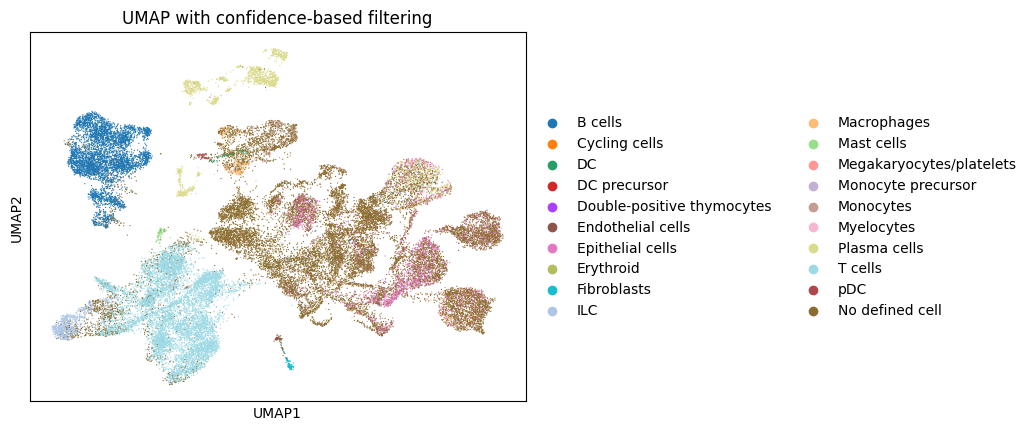

final_labels
No defined cell               16891
T cells                        8678
B cells                        4732
Epithelial cells               2806
Plasma cells                   2299
ILC                             910
Macrophages                     567
Monocytes                       229
Mast cells                       86
Fibroblasts                      85
DC                               70
pDC                              59
Endothelial cells                55
Myelocytes                       10
Erythroid                         2
Double-positive thymocytes        1
Megakaryocytes/platelets          1
Cycling cells                     0
DC precursor                      0
Monocyte precursor                0
Name: count, dtype: int64


In [258]:
import anndata as ad
# 'final_labels'을 Categorical로 변환
adata.obs['final_labels'] = adata.obs['predicted_labels'].astype('category')

# 이미 'No defined cell'이 카테고리에 포함되어 있는지 확인
if "No defined cell" not in adata.obs['final_labels'].cat.categories:
    adata.obs['final_labels'] = adata.obs['final_labels'].cat.add_categories("No defined cell")  # 새 카테고리 추가

# conf_score 0.5 미만인 경우 "No defined cell"로 설정
adata.obs.loc[adata.obs['conf_score'] < 0.80 ,'final_labels'] = "No defined cell"
sc.pl.umap(adata, color='final_labels', title='UMAP with confidence-based filtering')
# 결과 확인
print(adata.obs['final_labels'].value_counts())


In [226]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,predicted_doublet,leiden,leiden_res_0.02,leiden_res_0.50,leiden_res_2.00,predicted_labels,over_clustering,majority_voting,conf_score,final_labels
SMC01-T_AAACCTGCATACGCCG,GSE132465_SMC01-T,4866,8.490233,38052,10.546735,34.308315,46.541575,58.774834,72.122359,4917,...,False,0,0,0,0,Macrophages,90,Macrophages,0.526996,No defined cell
SMC01-T_AAACCTGGTCGCATAT,GSE132465_SMC01-T,5268,8.569596,33750,10.426765,28.989630,40.865185,52.376296,65.709630,2957,...,False,0,0,0,0,Epithelial cells,90,Macrophages,0.862743,Epithelial cells
SMC01-T_AAACCTGTCCCTTGCA,GSE132465_SMC01-T,1714,7.447168,7356,8.903408,47.933660,61.215334,70.962480,82.164220,1450,...,False,0,0,0,2,Macrophages,206,Macrophages,0.144739,No defined cell
SMC01-T_AAACGGGAGGGAAACA,GSE132465_SMC01-T,1229,7.114769,3752,8.230311,36.913646,51.305970,64.365672,80.570362,358,...,False,0,0,2,2,Epithelial cells,90,Macrophages,0.580689,No defined cell
SMC01-T_AAACGGGGTATAGGTA,GSE132465_SMC01-T,3914,8.272571,23991,10.085476,36.993039,46.759201,58.342712,72.297945,4154,...,False,0,0,0,0,Macrophages,102,Macrophages,0.334009,No defined cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMC25-T_TTTGGTTCAACGCACC,GSE132465_SMC25-T,1814,7.503841,17929,9.794231,75.497797,81.744659,86.697529,91.750795,536,...,False,29,4,16,36,Plasma cells,25,Plasma cells,0.997034,Plasma cells
SMC25-T_TTTGTCAAGCGCTCCA,GSE132465_SMC25-T,829,6.721426,2001,7.601902,41.079460,55.022489,66.816592,83.558221,72,...,False,26,5,17,32,B cells,199,B cells,0.998273,B cells
SMC06-T_TCTTCGGCAAACAACA,GSE132465_SMC06-T,1221,7.108244,4034,8.302762,44.471988,57.263262,69.310858,82.126921,136,...,False,15,3,10,20,Mast cells,48,T cells,0.977829,Mast cells
SMC07-T_TGAGAGGGTTTAGGAA,GSE132465_SMC07-T,1003,6.911747,2967,7.995644,47.623862,57.633974,68.823728,83.046849,285,...,False,25,3,11,22,Mast cells,184,T cells,0.967219,Mast cells


Cluster 0: ['EPCAM', 'S100A10', 'MT-ND3', 'S100A6', 'MT-ATP6', 'MT-CO3', 'KRT18', 'MT-ND1', 'CST3', 'GPX2']
Cluster 1: ['G0S2', 'FTH1', 'CXCL8', 'NAMPT', 'SOD2', 'NEAT1', 'SRGN', 'SAT1', 'S100A9', 'BCL2A1']
Cluster 2: ['TYROBP', 'HLA-DRA', 'TYMP', 'HLA-DPA1', 'FCER1G', 'CD74', 'HLA-DPB1', 'IFI30', 'NPC2', 'CST3']
Cluster 3: ['IGKC', 'MT-CO3', 'MT-ATP6', 'MT-ND1', 'IGHA2', 'MT-ND2', 'MT-CYB', 'MT-ND4', 'MT-CO2', 'MT-CO1']
Cluster 4: ['B2M', 'RPL41', 'CCL5', 'RPS10', 'RPS29', 'MT-ATP6', 'SRGN', 'TMSB4X', 'CD2', 'CST7']
Cluster 5: ['MT-ATP6', 'MT-ND4', 'MT-ND3', 'MT-CYB', 'MT-CO2', 'MT-CO1', 'MT-CO3', 'MT-ND1', 'MT-ND2', 'MT-ND5']
Cluster 6: ['RPL41', 'RPS10', 'RPS29', 'RPL27A', 'RPL9', 'RPL23', 'RPL13A', 'RPS11', 'RPS20', 'RPL21']
Cluster 7: ['SSR4', 'MZB1', 'FKBP11', 'SEC11C', 'DERL3', 'JCHAIN', 'PRDX4', 'XBP1', 'TXNDC5', 'IGKC']
Cluster 8: ['IGFBP7', 'CALD1', 'IFITM3', 'SPARC', 'MT-ATP6', 'LGALS1', 'MT-ND3', 'CD63', 'ITGB1', 'VIM']
Cluster 9: ['IGKC', 'MALAT1', 'IGLC2', 'IGHG3', 'B2M',

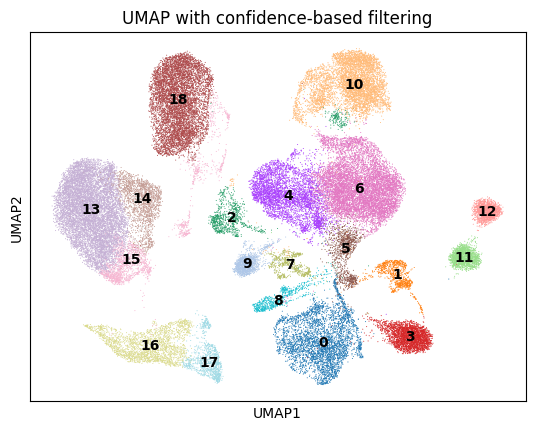

In [154]:
import scanpy as sc
sc.tl.rank_genes_groups(adata, groupby='leiden_res_0.50', method='t-test')  # 또는 'wilcoxon'
# 각 클러스터별 상위 10개 유전자 추출
top_genes = {}

groups = adata.uns['rank_genes_groups']['names'].dtype.names  # 클러스터 이름들

for group in groups:
    genes = adata.uns['rank_genes_groups']['names'][group][:10]
    top_genes[group] = genes.tolist()

# 결과 확인
for cluster, genes in top_genes.items():
    print(f"Cluster {cluster}: {genes}")
sc.pl.umap(
    adata,
    color='leiden_res_0.50',
    title='UMAP with confidence-based filtering',
    legend_loc='on data'  # 또는 'right margin', 'none'
)


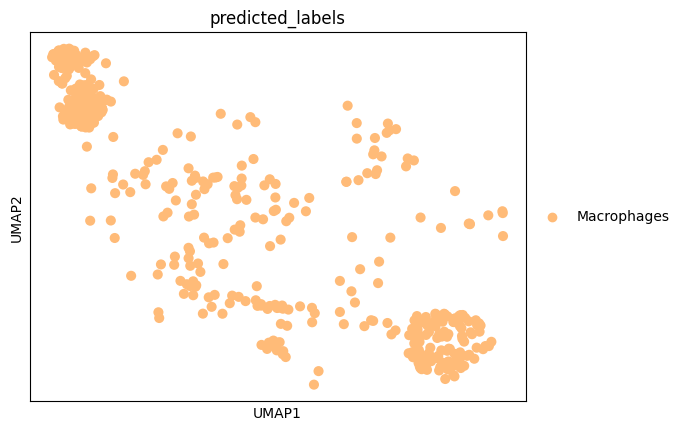

In [259]:
import scanpy as sc

# DC만 필터링
dc_cells = adata[adata.obs['final_labels'] == 'Macrophages']

# UMAP 그리기
sc.pl.umap(dc_cells, color=['predicted_labels'])


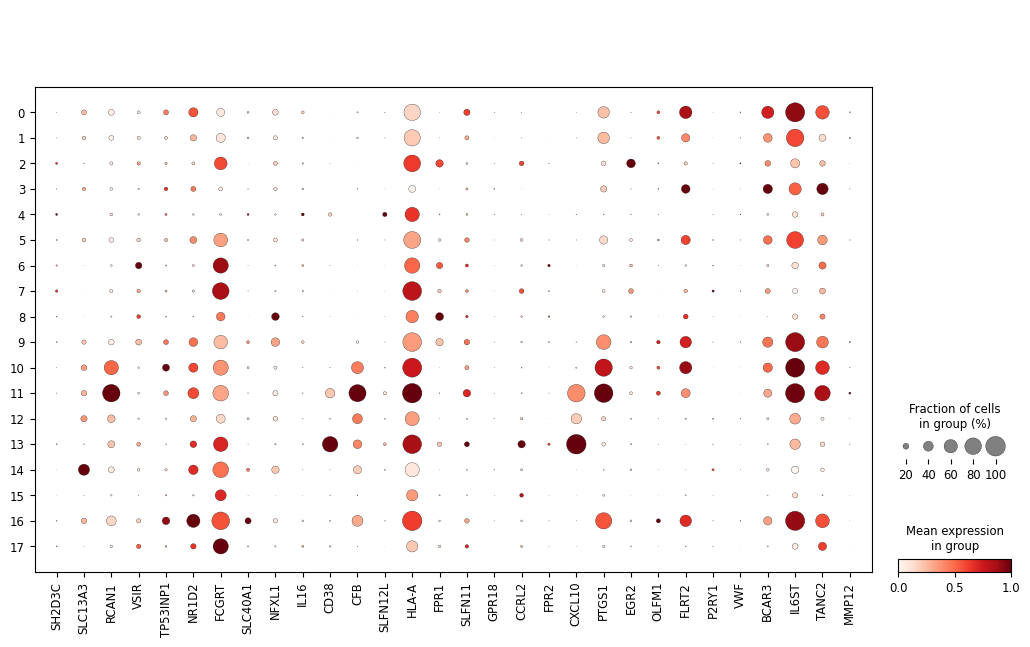

In [95]:
import scanpy as sc

# 특정 세포 유형의 marker gene 리스트
marker_genes = {
    "M0": ["SH2D3C", "SLC13A3", "RCAN1", "VSIR", "TP53INP1", "NR1D2", "FCGRT","SLC40A1", "NFXL1", "IL16"],
    'M1' : ["CD38", "CFB", "SLFN12L", "HLA-A", "FPR1", "SLFN11", "GPR18", "CCRL2","FPR2", "CXCL10"],
    'M2' : ["PTGS1", "EGR2", "OLFM1", "FLRT2", "P2RY1", "VWF", "BCAR3", "IL6ST", "TANC2", "MMP12"]
}

# 'Macrophage'라는 키로 다시 묶기
filtered_genes["Macrophage"] = filtered_genes["M0"] + filtered_genes["M1"] + filtered_genes["M2"]

# dotplot
sc.pl.dotplot(
    adata,
    var_names=filtered_genes["Macrophage"],
    groupby="leiden_res_0.50",
    standard_scale="var"
)


In [260]:
# 조건을 만족하는 세포 선택
macrophage_cells = (adata.obs['final_labels'] == 'Macrophages')

# 조건에 맞는 세포만 새로운 AnnData 객체로 저장
Macrophage = adata[macrophage_cells].copy()

# 결과 확인
print(f"Filtered Macrophage object shape: {Macrophage.shape}")


Filtered Macrophage object shape: (567, 23495)


In [261]:
# rawadata.obs.index = rawadata.obs['sample'].astype(str) + "_" + rawadata.obs.index.astype(str)
# rawadata = rawadata[rawadata.obs.index.isin(adata.obs.index)].copy()
rawadata.obs['cell_type'] = 'NaN'

# Macrophage 객체와 인덱스가 겹치는 경우 "Macrophage"로 변경
rawadata.obs.loc[rawadata.obs.index.isin(Macrophage.obs.index), 'cell_type'] = 'Macrophage'

# 결과 확인
print(rawadata.obs['cell_type'].value_counts())


cell_type
NaN           38614
Macrophage      567
Name: count, dtype: int64


In [262]:
rawadata = rawadata[rawadata.obs['cell_type'] != 'NaN']
print(rawadata.obs['cell_type'].value_counts())
rawadata

cell_type
Macrophage    567
Name: count, dtype: int64


View of AnnData object with n_obs × n_vars = 567 × 33538
    obs: 'sample', 'cell_type'
    var: 'gene_ids', 'feature_types'
    layers: 'counts'

In [263]:
rawadata.obs = rawadata.obs[['sample','cell_type']]
rawadata

AnnData object with n_obs × n_vars = 567 × 33538
    obs: 'sample', 'cell_type'
    var: 'gene_ids', 'feature_types'
    layers: 'counts'

In [268]:
rawadata.layers.clear()

In [274]:
import pandas as pd

rawadata.var = pd.DataFrame(index=rawadata.var_names)


In [277]:
from scipy.sparse import csr_matrix
rawadata.X = csr_matrix(rawadata.X)
rawadata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 1327423 stored elements and shape (567, 33538)>

In [278]:
gene_list = [
    "CXCL9", "UBD", "PRM1", "IRGM", "KRT16", "PCP4", "IDO1", "APOL2", "IL23R", "SCT", "HEATR9", "MSX1", "KCND3", 
    "IL31RA", "RETNLB", "RNASE2", "SCN3A", "TMEM26", "CDH1", "ARG1", "CHI3L1", "RBP4", "CLDN11", "CCL17", "CLEC10A", 
    "CTNND2", "KCNE3", "IGFBP4", "DKK2", "PCP4L1", "KMO", "ARAP3", "GPR34", "SLC40A1", "ENHO", "ARHGAP19", "SH2D3C", 
    "SLC13A3", "RCAN1", "VSIR", "NR1D2", "FCGRT", "SLC40A1", "NFXL1", "IL16", "CD38", "CFB", "SLFN12L", "HLA-A", 
    "FPR1", "SLFN11", "GPR18", "CCRL2", "FPR2", "CXCL10", "PTGS1", "EGR2", "OLFM1", "FLRT2", "P2RY1", "VWF", "BCAR3", 
    "IL6ST", "TANC2", "MMP12"
]
# 🔹 gene_list에 있는 유전자 중 rawadata.var_names에 없는 것 찾기
missing_genes = [gene for gene in gene_list if gene not in rawadata.var_names]

# 🔹 결과 출력
print(f"Missing genes count: {len(missing_genes)}")
print("Missing genes:", missing_genes[:10])  # 상위 10개만 출력
save_path = "/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Macrophage_7.h5ad"

# 🔹 AnnData 객체 저장
rawadata.write(save_path)

print(f"File saved successfully at: {save_path}")



... storing 'cell_type' as categorical


Missing genes count: 0
Missing genes: []
File saved successfully at: /home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Macrophage_7.h5ad


In [265]:
import scanpy as sc

adataM = sc.read_h5ad("/home/Data_Drive_8TB/kykim/colon/Macspectrum/Public_predict/Macrophage_5.h5ad")


In [266]:
adataM

AnnData object with n_obs × n_vars = 399 × 23828
    obs: 'sample', 'cell_type'